**Punto 1**

=== Punto 1 – Procesamiento de Imágenes (script .py listo para Colab) ===
Modo Colab detectado. Se abrirá diálogo para subir archivos.


Saving test_image.jpg to test_image (2).jpg
Imagen cargada: test_image (2).jpg  Tamaño: (432, 768, 3)
Iniciando pipeline de procesamiento...


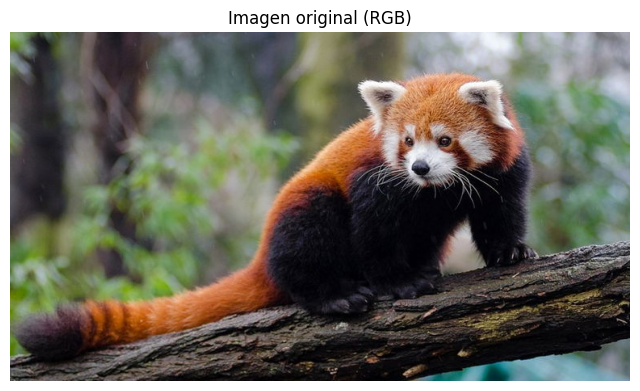

Aplicando filtros: suavizado (Gaussian Blur) y realce (sharpen).


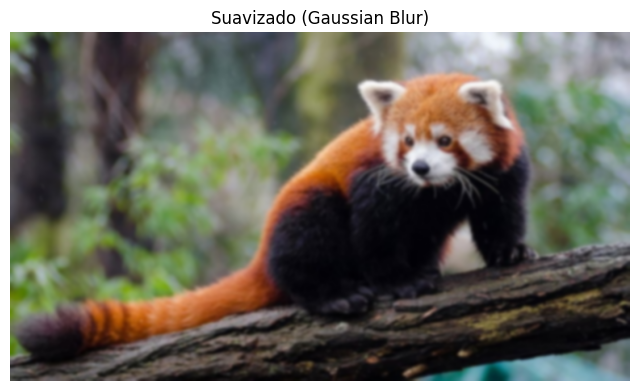

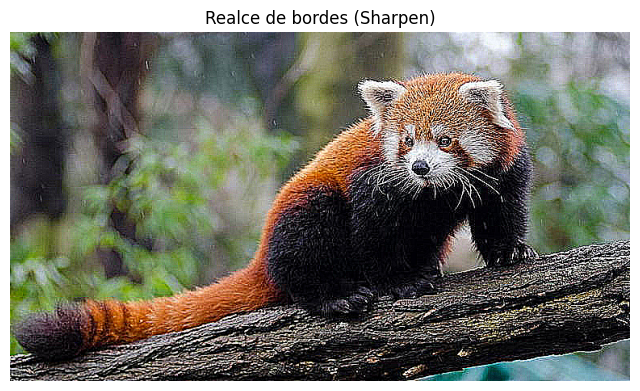

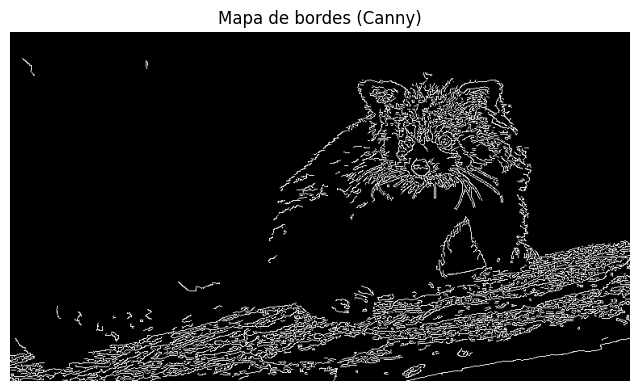


Observaciones rápidas (ejemplos):
- Suavizado: reduce ruido y detalles finos; texturas menos definidas.
- Realce (sharpen): aumenta contraste local y hace aristas más nítidas; puede acentuar ruido.
- Canny: resalta contornos significativos.

Separando canales R, G, B y mostrándolos en escala de grises.


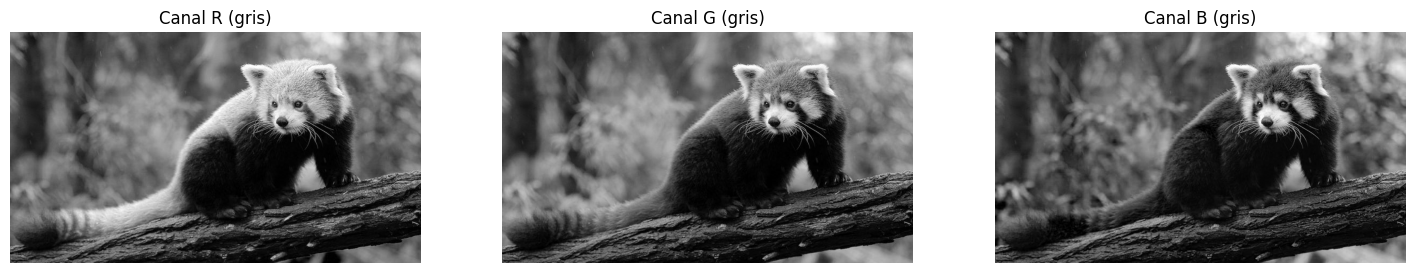


Breve explicación:
- Canal R: zonas rojizas/tonos cálidos aparecen más claras.
- Canal G: resalta vegetación y muchos detalles de textura.
- Canal B: tonos fríos y sombras azuladas aparecen más claras.

Operaciones morfológicas: binarizando con Otsu y aplicando opening y closing.


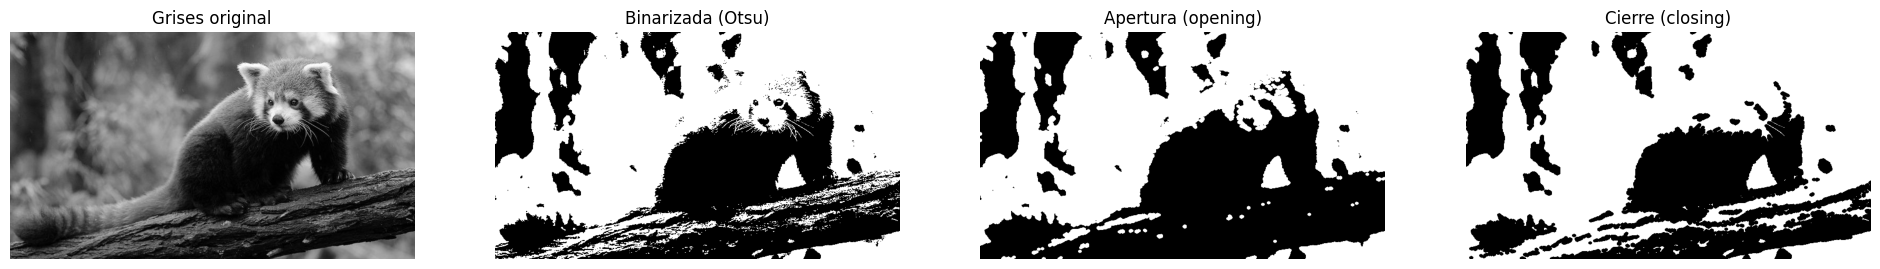


Efectos (resumen):
- Opening: elimina pequeñas manchas blancas (ruido) y puede adelgazar objetos finos.
- Closing: rellena pequeños huecos dentro de objetos blancos, une regiones fragmentadas.

Generando GIF con la secuencia: original -> suavizado -> realce -> binarizada -> opening -> closing -> bordes
GIF creado y guardado en: resultados_secuencia.gif


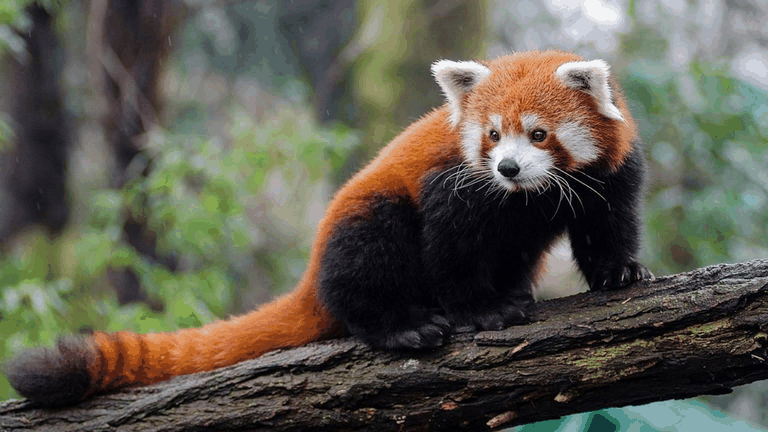


Proceso completado.


In [3]:
import io
import os
import sys
import traceback
from typing import Optional

# Intentar importaciones comunes; si faltan, indicarlo claramente.
try:
    from PIL import Image, ImageFilter
except Exception:
    print("Pillow no está instalado. Ejecuta: pip install pillow")
    raise

import numpy as np
import matplotlib.pyplot as plt

# Intentar importar OpenCV; si no está, intentar instalarlo automáticamente (solo en entornos con pip).
try:
    import cv2
except Exception:
    print("OpenCV no encontrado. Intentando instalar opencv-python...")
    try:
        import subprocess
        subprocess.check_call([sys.executable, "-m", "pip", "install", "opencv-python-headless"])
        import cv2  # retry
    except Exception:
        print("No se pudo instalar OpenCV automáticamente. Instálalo manualmente e intenta de nuevo.")
        raise

# imageio para crear GIFs
try:
    import imageio
except Exception:
    print("imageio no encontrado. Intentando instalar imageio...")
    try:
        import subprocess
        subprocess.check_call([sys.executable, "-m", "pip", "install", "imageio"])
        import imageio
    except Exception:
        print("No se pudo instalar imageio automáticamente. Instálalo manualmente e intenta de nuevo.")
        raise

# IPython display (útil en Colab para mostrar GIFs)
try:
    from IPython.display import display, Image as IPyImage
except Exception:
    # No crítico fuera de notebooks
    def display(x):
        print("Display no disponible fuera de IPython/Jupyter.")
    IPyImage = None

# Intentar importar helper de Colab para upload; si no existe, haremos fallback.
IS_COLAB = False
try:
    from google.colab import files as colab_files  # type: ignore
    IS_COLAB = True
except Exception:
    IS_COLAB = False

# -------------------------
# Funciones auxiliares
# -------------------------
def upload_image_interactive() -> Optional[np.ndarray]:
    """
    Solicita subir un archivo y devuelve la imagen como array RGB (uint8).
    """
    if IS_COLAB:
        uploaded = colab_files.upload()
        if not uploaded:
            print("No se subió ningún archivo.")
            return None
        # Tomar el primer archivo subido
        first_filename = next(iter(uploaded))
        img_pil = Image.open(io.BytesIO(uploaded[first_filename])).convert("RGB")
        img = np.array(img_pil)
        print(f"Imagen cargada: {first_filename}  Tamaño: {img.shape}")
        return img
    else:
        print("No se detectó entorno Colab.")
        choice = input("¿Deseas (1) introducir ruta local de imagen o (2) cargar desde URL? [1/2]: ").strip()
        if choice == "1":
            path = input("Introduce la ruta local a la imagen: ").strip()
            if not os.path.exists(path):
                print("Ruta no encontrada.")
                return None
            img_pil = Image.open(path).convert("RGB")
            img = np.array(img_pil)
            return img
        elif choice == "2":
            url = input("Introduce la URL de la imagen: ").strip()
            try:
                from urllib.request import urlopen
                resp = urlopen(url)
                img_pil = Image.open(io.BytesIO(resp.read())).convert("RGB")
                img = np.array(img_pil)
                return img
            except Exception as e:
                print("No se pudo descargar la imagen desde la URL:", e)
                return None
        else:
            print("Opción no válida.")
            return None

def show_image_cv_rgb(img_rgb: np.ndarray, title: str = ""):
    """Muestra una imagen RGB (uint8) con matplotlib."""
    plt.figure(figsize=(8,6))
    plt.imshow(img_rgb)
    plt.title(title)
    plt.axis("off")
    plt.show()

def ensure_uint8(arr: np.ndarray) -> np.ndarray:
    a = np.clip(arr, 0, 255).astype(np.uint8)
    return a

def to_rgb_image_from_gray(gray: np.ndarray) -> np.ndarray:
    if gray.ndim == 2:
        return np.stack([gray]*3, axis=-1)
    return gray

# -------------------------
# Procesamiento principal
# -------------------------
def process_image_pipeline(img: np.ndarray, output_gif_path: str = "resultados_secuencia.gif"):
    """
    Ejecuta la cadena completa de procesamiento y muestra resultados.
    Devuelve el path del gif creado.
    """
    print("Iniciando pipeline de procesamiento...")
    img = ensure_uint8(img)
    show_image_cv_rgb(img, "Imagen original (RGB)")

    # Filtros básicos
    print("Aplicando filtros: suavizado (Gaussian Blur) y realce (sharpen).")
    # Gaussian blur (ksize impar)
    blur = cv2.GaussianBlur(img, ksize=(9,9), sigmaX=0)
    show_image_cv_rgb(blur, "Suavizado (Gaussian Blur)")

    # Sharpen (filtro de realce)
    kernel_sharpen = np.array([[-1,-1,-1],
                               [-1, 9,-1],
                               [-1,-1,-1]])
    sharpen = cv2.filter2D(img, ddepth=-1, kernel=kernel_sharpen)
    sharpen = ensure_uint8(sharpen)
    show_image_cv_rgb(sharpen, "Realce de bordes (Sharpen)")

    # Mapa de bordes con Canny (trabaja sobre escala de grises)
    img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(img_gray, threshold1=100, threshold2=200)
    plt.figure(figsize=(8,6))
    plt.imshow(edges, cmap="gray")
    plt.title("Mapa de bordes (Canny)")
    plt.axis("off")
    plt.show()

    print("\nObservaciones rápidas (ejemplos):")
    print("- Suavizado: reduce ruido y detalles finos; texturas menos definidas.")
    print("- Realce (sharpen): aumenta contraste local y hace aristas más nítidas; puede acentuar ruido.")
    print("- Canny: resalta contornos significativos.")

    # Visualización de canales R, G, B
    print("\nSeparando canales R, G, B y mostrándolos en escala de grises.")
    R = img[:,:,0]
    G = img[:,:,1]
    B = img[:,:,2]
    fig, axes = plt.subplots(1,3, figsize=(18,6))
    axes[0].imshow(R, cmap="gray"); axes[0].axis("off"); axes[0].set_title("Canal R (gris)")
    axes[1].imshow(G, cmap="gray"); axes[1].axis("off"); axes[1].set_title("Canal G (gris)")
    axes[2].imshow(B, cmap="gray"); axes[2].axis("off"); axes[2].set_title("Canal B (gris)")
    plt.show()

    print("\nBreve explicación:")
    print("- Canal R: zonas rojizas/tonos cálidos aparecen más claras.")
    print("- Canal G: resalta vegetación y muchos detalles de textura.")
    print("- Canal B: tonos fríos y sombras azuladas aparecen más claras.")

    # Operaciones morfológicas sobre versión binarizada
    print("\nOperaciones morfológicas: binarizando con Otsu y aplicando opening y closing.")
    gray = img_gray
    # Umbral Otsu
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Kernel morfológico
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7,7))
    opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
    closing = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

    fig, axes = plt.subplots(1,4, figsize=(24,6))
    axes[0].imshow(gray, cmap="gray"); axes[0].axis("off"); axes[0].set_title("Grises original")
    axes[1].imshow(binary, cmap="gray"); axes[1].axis("off"); axes[1].set_title("Binarizada (Otsu)")
    axes[2].imshow(opening, cmap="gray"); axes[2].axis("off"); axes[2].set_title("Apertura (opening)")
    axes[3].imshow(closing, cmap="gray"); axes[3].axis("off"); axes[3].set_title("Cierre (closing)")
    plt.show()

    print("\nEfectos (resumen):")
    print("- Opening: elimina pequeñas manchas blancas (ruido) y puede adelgazar objetos finos.")
    print("- Closing: rellena pequeños huecos dentro de objetos blancos, une regiones fragmentadas.")

    # Preparar frames y crear GIF
    print("\nGenerando GIF con la secuencia: original -> suavizado -> realce -> binarizada -> opening -> closing -> bordes")
    frames = []
    def pil_from_arr(arr):
        if isinstance(arr, Image.Image):
            return arr.convert("RGB")
        arr = np.asarray(arr)
        if arr.ndim == 2:
            arr_rgb = np.stack([arr]*3, axis=-1)
        else:
            arr_rgb = arr
        arr_rgb = ensure_uint8(arr_rgb)
        return Image.fromarray(arr_rgb)

    frames.append(pil_from_arr(img))                      # original
    frames.append(pil_from_arr(blur))                     # blur
    frames.append(pil_from_arr(sharpen))                  # sharpen
    frames.append(pil_from_arr(binary))                   # binarizada
    frames.append(pil_from_arr(opening))                  # opening
    frames.append(pil_from_arr(closing))                  # closing
    frames.append(pil_from_arr(np.stack([edges]*3, -1)))  # edges as RGB

    # Guardar GIF
    try:
        # imageio.mimsave acepta numpy arrays; usamos PIL images => convertimos
        imageio.mimsave(output_gif_path, [np.array(f) for f in frames], duration=0.8)
        print(f"GIF creado y guardado en: {output_gif_path}")
    except Exception as e:
        print("Error guardando GIF con imageio:", e)
        print("Intentando guardar con PIL...")
        try:
            frames[0].save(output_gif_path, save_all=True, append_images=frames[1:], duration=800, loop=0)
            print(f"GIF guardado con PIL en: {output_gif_path}")
        except Exception as e2:
            print("Error guardando GIF con PIL:", e2)
            print("No se pudo crear el GIF.")

    # Mostrar GIF si estamos en notebook
    if IPyImage is not None and os.path.exists(output_gif_path):
        try:
            display(IPyImage(filename=output_gif_path))
        except Exception:
            print("No se pudo mostrar el GIF en el entorno actual.")
    else:
        if os.path.exists(output_gif_path):
            print(f"Puedes descargar el GIF desde el sistema de archivos: ./{output_gif_path}")

    return output_gif_path

# -------------------------
# Entrypoint
# -------------------------
def main():
    print("=== Punto 1 – Procesamiento de Imágenes (script .py listo para Colab) ===")
    try:
        img = upload_image_interactive()
        if img is None:
            print("\nNo se cargó imagen. Para ejecutar con una imagen de ejemplo automática, se intentará descargar una imagen de tigre (Wikimedia).")
            try:
                from urllib.request import urlopen
                sample_url = "https://upload.wikimedia.org/wikipedia/commons/6/6d/Amur_tiger_in_Sikhote-Alin%2C_Russia.jpg"
                resp = urlopen(sample_url)
                img_pil = Image.open(io.BytesIO(resp.read())).convert("RGB")
                img = np.array(img_pil)
                print("Imagen de ejemplo cargada desde internet.")
            except Exception as e:
                print("No se pudo cargar la imagen de ejemplo. Saliendo.")
                traceback.print_exc()
                return

        # Ejecutar pipeline
        gif_path = process_image_pipeline(img, output_gif_path="resultados_secuencia.gif")

        # Si estamos en Colab, ofrecer descarga automática
        if IS_COLAB and os.path.exists(gif_path):
            try:
                from google.colab import files
                files.download('{gif_path}')
            except Exception:
                pass

        print("\nProceso completado.")
    except Exception as e:
        print("Ocurrió un error durante la ejecución:", e)
        traceback.print_exc()

if __name__ == "__main__":
    main()